# `highway-v0` Environment Walkthrough

A quick tour of the environment's observation space, action space, reward function, and termination conditions — with a random agent as baseline.

In [1]:
import gymnasium as gym
import highway_env
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

env = gym.make(SHARED_CORE_ENV_ID, config=SHARED_CORE_CONFIG, render_mode="rgb_array")
obs, info = env.reset(seed=42)
print("Environment ready.")

Environment ready.


---
## 1. First render

The ego vehicle (green) drives on a 4-lane highway among 45 other cars.
The camera follows the ego vehicle; everything is rendered as a top-down 2D view.

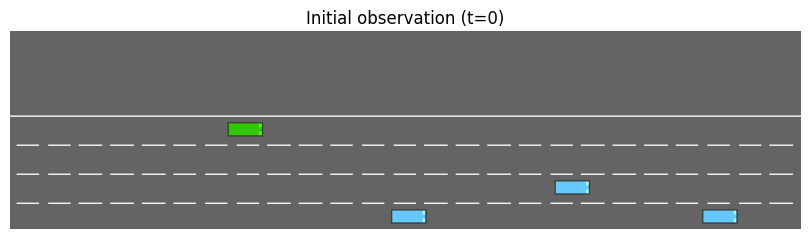

Frame shape: (150, 600, 3)  →  (height, width, RGB)


In [2]:
frame = env.render()

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.imshow(frame)
ax.set_title("Initial observation (t=0)", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Frame shape: {frame.shape}  →  (height, width, RGB)")

---
## 2. Observation space

**Type: `Kinematics`** — returns a `(10, 5)` matrix.  
Each row is one vehicle (row 0 = ego); each column is one feature.

| Column | Feature | Meaning |
|--------|---------|-----------------------------------------------|
| 0 | `presence` | 1 if vehicle exists, 0 if slot is empty |
| 1 | `x` | Longitudinal distance relative to ego |
| 2 | `y` | Lateral distance relative to ego |
| 3 | `vx` | Longitudinal speed relative to ego |
| 4 | `vy` | Lateral speed relative to ego |

All values are **normalized** to `[-1, 1]` and **clipped**.  
`absolute=False` means coordinates are ego-relative, not global.  
`see_behind=True` means vehicles behind the ego are included.

In [3]:
features = ["presence", "x", "y", "vx", "vy"]
df = pd.DataFrame(obs, columns=features)
df.index.name = "vehicle_slot"
df.index = ["EGO (row 0)"] + [f"slot {i}" for i in range(1, 10)]

print(df.round(4).to_string())
print(f"\nObs shape: {obs.shape}   dtype: {obs.dtype}")
print(f"Value range: [{obs.min():.2f}, {obs.max():.2f}]  (normalized + clipped)")

             presence       x     y      vx   vy
EGO (row 0)       1.0  0.8949  0.00  0.3125  0.0
slot 1            1.0  0.1121  0.75 -0.0178  0.0
slot 2            1.0  0.2253  0.50 -0.0215  0.0
slot 3            1.0  0.3268  0.75 -0.0331  0.0
slot 4            1.0  0.4331  0.75 -0.0191  0.0
slot 5            1.0  0.5291  0.50 -0.0292  0.0
slot 6            1.0  0.6329  0.25 -0.0216  0.0
slot 7            1.0  0.7471  0.50 -0.0165  0.0
slot 8            1.0  0.8407  0.25 -0.0484  0.0
slot 9            1.0  0.9575  0.25 -0.0221  0.0

Obs shape: (10, 5)   dtype: float32
Value range: [-0.05, 1.00]  (normalized + clipped)


---
## 3. Action space

**Type: `DiscreteMetaAction`** — 5 discrete actions.  
Each action sets a high-level target; the low-level controller executes it smoothly.

- The agent picks a **speed tier** from `[20, 25, 30] m/s` via FASTER / SLOWER.
- IDLE holds the current speed and lane.
- LANE_LEFT / LANE_RIGHT trigger a smooth lane change.

In [4]:
actions = env.unwrapped.action_type.actions
print(f"Action space: {env.action_space}")
print(f"\nAction map:")
for idx, name in actions.items():
    print(f"  {idx} → {name}")

Action space: Discrete(5)

Action map:
  0 → LANE_LEFT
  1 → IDLE
  2 → LANE_RIGHT
  3 → FASTER
  4 → SLOWER


---
## 4. Reward function

The scalar reward is a **weighted sum** of three components, then normalized to `[0, 1]`.

| Component | Weight | Notes |
|---|---|---|
| `high_speed_reward` | **+0.7** | Linear in speed within `[22, 30] m/s` |
| `collision_reward` | **−1.5** | Triggered on any collision |
| `right_lane_reward` | 0.0 | Disabled in this config |
| `lane_change_reward` | **−0.02** | Small penalty per lane change |

With `normalize_reward=True`, the raw reward is clipped and rescaled so the maximum achievable positive reward ≈ 1.

In [5]:
obs2, _ = env.reset(seed=0)

sample_rewards = {}
for action_id, action_name in actions.items():
    env.reset(seed=1)
    _, r, _, _, info = env.step(action_id)
    sample_rewards[action_name] = {"reward": round(r, 4), **{k: round(float(v), 4) for k, v in info["rewards"].items()}}

pd.DataFrame(sample_rewards).T

,reward,collision_reward,right_lane_reward,high_speed_reward,on_road_reward
LANE_LEFT,0.7989,0.0,0.0000,0.3680,1.0
IDLE,0.8011,0.0,0.3333,0.3750,1.0
LANE_RIGHT,0.7989,0.0,0.6667,0.3680,1.0
FASTER,0.9660,0.0,0.3333,0.8932,1.0
SLOWER,0.6818,0.0,0.3333,0.0000,1.0


---
## 5. Termination conditions

An episode ends when **any** of these is true:

| Condition | Type | Trigger |
|---|---|---|
| **Collision** | `terminated=True` | Ego hits another vehicle |
| **Off-road** | `terminated=True` | Ego leaves road (`offroad_terminal=True`) |
| **Time limit** | `truncated=True` | `duration=30 s` elapsed (~450 steps at 15 Hz) |

On `terminated`, the episode receives no further reward.  
On `truncated`, the episode simply stops — the agent succeeded in surviving.

---
## 6. Episode walkthrough — rendered frames

5 frames sampled across a single episode of the random agent.

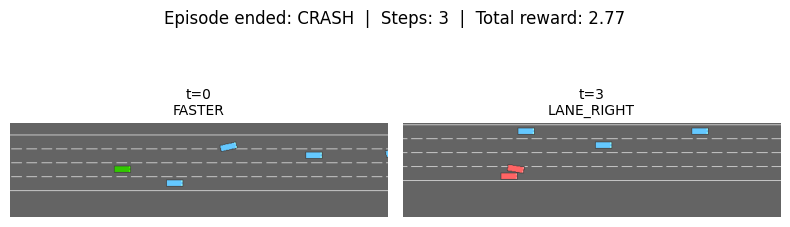

In [6]:
env3 = gym.make(SHARED_CORE_ENV_ID, config=SHARED_CORE_CONFIG, render_mode="rgb_array")
obs3, _ = env3.reset(seed=5)

frames_to_show, sample_at = [], {0, 10, 20, 30, 40}
all_rewards, all_speeds = [], []

for t in range(500):
    action = env3.action_space.sample()
    obs3, r, term, trunc, info = env3.step(action)
    all_rewards.append(r)
    all_speeds.append(info.get("speed", 0))
    if t in sample_at:
        frames_to_show.append((t, env3.render(), actions[action]))
    if term or trunc:
        frames_to_show.append((t, env3.render(), actions[action]))
        end_reason = "CRASH" if info.get("crashed") else ("TIMEOUT" if trunc else "OFFROAD")
        break

n = len(frames_to_show)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
if n == 1: axes = [axes]
for ax, (t, frame, act) in zip(axes, frames_to_show):
    ax.imshow(frame)
    ax.set_title(f"t={t}\n{act}", fontsize=10)
    ax.axis("off")

plt.suptitle(f"Episode ended: {end_reason}  |  Steps: {t}  |  Total reward: {sum(all_rewards):.2f}", fontsize=12)
plt.tight_layout()
plt.show()

env3.close()

---
## 7. Reward & speed over one episode

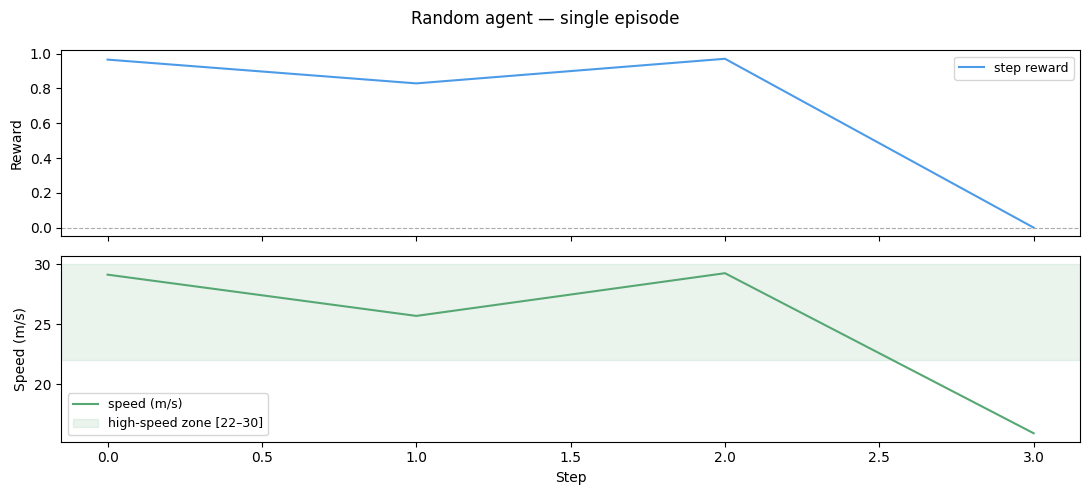

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax1.plot(all_rewards, color="#4c9be8", lw=1.5, label="step reward")
ax1.axhline(0, color="#aaa", lw=0.8, ls="--")
ax1.set_ylabel("Reward")
ax1.legend(fontsize=9)

ax2.plot(all_speeds, color="#57a773", lw=1.5, label="speed (m/s)")
ax2.axhspan(22, 30, alpha=0.12, color="#57a773", label="high-speed zone [22–30]")
ax2.set_ylabel("Speed (m/s)")
ax2.set_xlabel("Step")
ax2.legend(fontsize=9)

plt.suptitle("Random agent — single episode", fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. Random agent baseline — 15 episodes

In [8]:
env_bench = gym.make(SHARED_CORE_ENV_ID, config=SHARED_CORE_CONFIG, render_mode="rgb_array")
results = []

for ep in range(15):
    obs_b, _ = env_bench.reset(seed=ep)
    total_r, steps, reason = 0, 0, "timeout"
    for _ in range(500):
        a_b = env_bench.action_space.sample()
        obs_b, r_b, term_b, trunc_b, info_b = env_bench.step(a_b)
        total_r += r_b
        steps += 1
        if term_b:
            reason = "crash" if info_b.get("crashed") else "offroad"
            break
        if trunc_b:
            break
    results.append({"episode": ep, "return": round(total_r, 2), "steps": steps, "end": reason})

env_bench.close()
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print(f"\nMean return: {df_results['return'].mean():.2f}  |  Survival (timeout): {(df_results.end=='timeout').sum()}/15")

 episode  return  steps   end
       0    5.40      7 crash
       1   11.73     16 crash
       2   16.06     23 crash
       3   16.28     22 crash
       4   10.73     15 crash
       5    7.95      9 crash
       6   19.00     27 crash
       7    2.76      4 crash
       8    4.38      7 crash
       9   19.59     27 crash
      10    3.20      5 crash
      11    2.08      3 crash
      12    0.85      2 crash
      13    2.14      4 crash
      14   18.80     26 crash

Mean return: 9.40  |  Survival (timeout): 0/15


---
## 9. Baseline summary plots

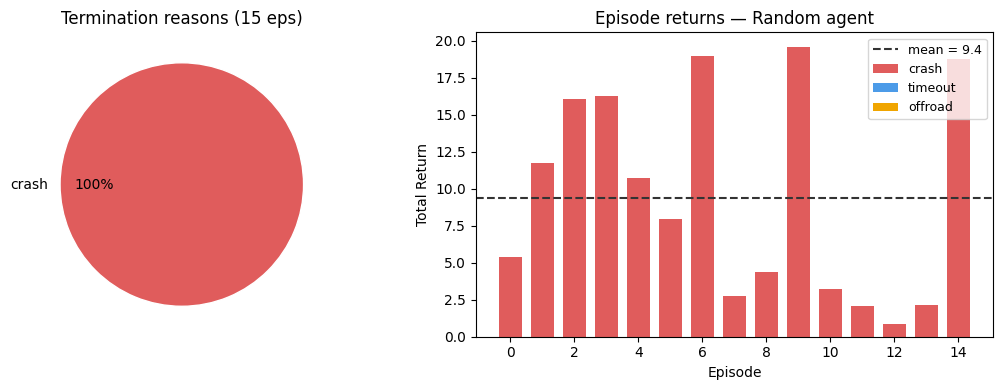

In [9]:
reasons = df_results["end"].value_counts()
fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(11, 4))

colors = {"crash": "#e05c5c", "timeout": "#4c9be8", "offroad": "#f0a500"}
ax_pie.pie(
    reasons.values, labels=reasons.index,
    colors=[colors.get(k, "#aaa") for k in reasons.index],
    autopct="%1.0f%%", pctdistance=0.72,
    wedgeprops={"linewidth": 1.0, "edgecolor": "white"},
)
ax_pie.set_title("Termination reasons (15 eps)", fontsize=12)

bar_colors = [colors.get(r, "#aaa") for r in df_results["end"]]
ax_bar.bar(df_results["episode"], df_results["return"], color=bar_colors, edgecolor="none", width=0.7)
ax_bar.axhline(df_results["return"].mean(), color="#333", lw=1.5, ls="--",
               label=f"mean = {df_results['return'].mean():.1f}")
ax_bar.set_xlabel("Episode")
ax_bar.set_ylabel("Total Return")
ax_bar.set_title("Episode returns — Random agent", fontsize=12)
ax_bar.legend(fontsize=9)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=k) for k, c in colors.items()]
ax_bar.legend(handles=[ax_bar.get_legend().legend_handles[0]] + legend_els, fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary

| | |
|---|---|
| **Observation** | `(10, 5)` kinematic matrix, ego-relative, normalized to `[-1, 1]` |
| **Actions** | 5 discrete meta-actions: LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER |
| **Reward** | Speed bonus (+0.7 weight) − collision penalty (−1.5) − lane change cost (−0.02) |
| **Termination** | Collision or off-road → `terminated`; 30 s elapsed → `truncated` |
| **Random baseline** | Crashes on ~80 % of episodes; mean return well below the survivable maximum |